# Bootstrap demonstration
## Proof of concept of how to get fit uncertainty from bootstrapping

### Load RooFit namespace

In [1]:
using namespace RooFit;

### Suppress RooFit output

In [2]:
RooMsgService::instance().setGlobalKillBelow(RooFit::WARNING) ;


RooFit v3.60 -- Developed by Wouter Verkerke and David Kirkby 
                Copyright (C) 2000-2013 NIKHEF, University of California & Stanford University
                All rights reserved, please read http://roofit.sourceforge.net/license.txt



### Define simple Gaussian model on top of exponential background

In [3]:
RooRealVar M("M", "M", 100.0, 180.0);
RooRealVar Mean("Mean", "Mean", /*139.57*/139.27, 130.0, 150.0);
RooRealVar Sigma("Sigma", "Sigma", /*5.0*/5.0917, 2.0, 8.0);
RooGaussian Gauss("Gauss", "Gauss", M, Mean, Sigma);

In [4]:
double Yield = /*500.0*/528.58;
RooRealVar Nsig("Nsig", "Nsig", Yield, Yield*0.1, Yield*10.0);
RooExtendPdf ExGauss("ExGauss", "ExGauss", Gauss, Nsig);

In [5]:
RooRealVar c("c", "c", /*-0.03*/-0.030895, -0.06, -0.01);
RooExponential Exp("Exp", "Exp", M, c);

In [6]:
RooRealVar Nbkg("Nbkg", "Nbkg", /*2000.0*/1971.5, 1500.0, 2500.0);
RooExtendPdf ExExp("ExExp", "ExExp", Exp, Nbkg);

In [7]:
RooAddPdf Model("Model", "Model", RooArgList(ExGauss, ExExp), RooArgList(Nsig, Nbkg));

### Generate dataset

In [8]:
auto OriginalData = Model.generate(M);

In [9]:
std::vector<RooDataSet> ToyData;
std::size_t NumberToys = 1000;
ToyData.reserve(NumberToys);
for(std::size_t i = 0; i < NumberToys; i++) {
    ToyData.push_back(*Model.generate(M));
}

### Fit model to generated data

In [10]:
auto Results = Model.fitTo(*OriginalData, Save(), PrintEvalErrors(-1), PrintLevel(-1));

In [11]:
Results->Print();


  RooFitResult: minimized FCN value: -6634.43, estimated distance to minimum: 8.96858e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                  Mean    1.3945e+02 +/-  3.92e-01
                  Nbkg    2.0025e+03 +/-  5.54e+01
                  Nsig    4.9743e+02 +/-  3.97e+01
                 Sigma    5.1381e+00 +/-  4.34e-01
                     c   -3.1747e-02 +/-  1.28e-03



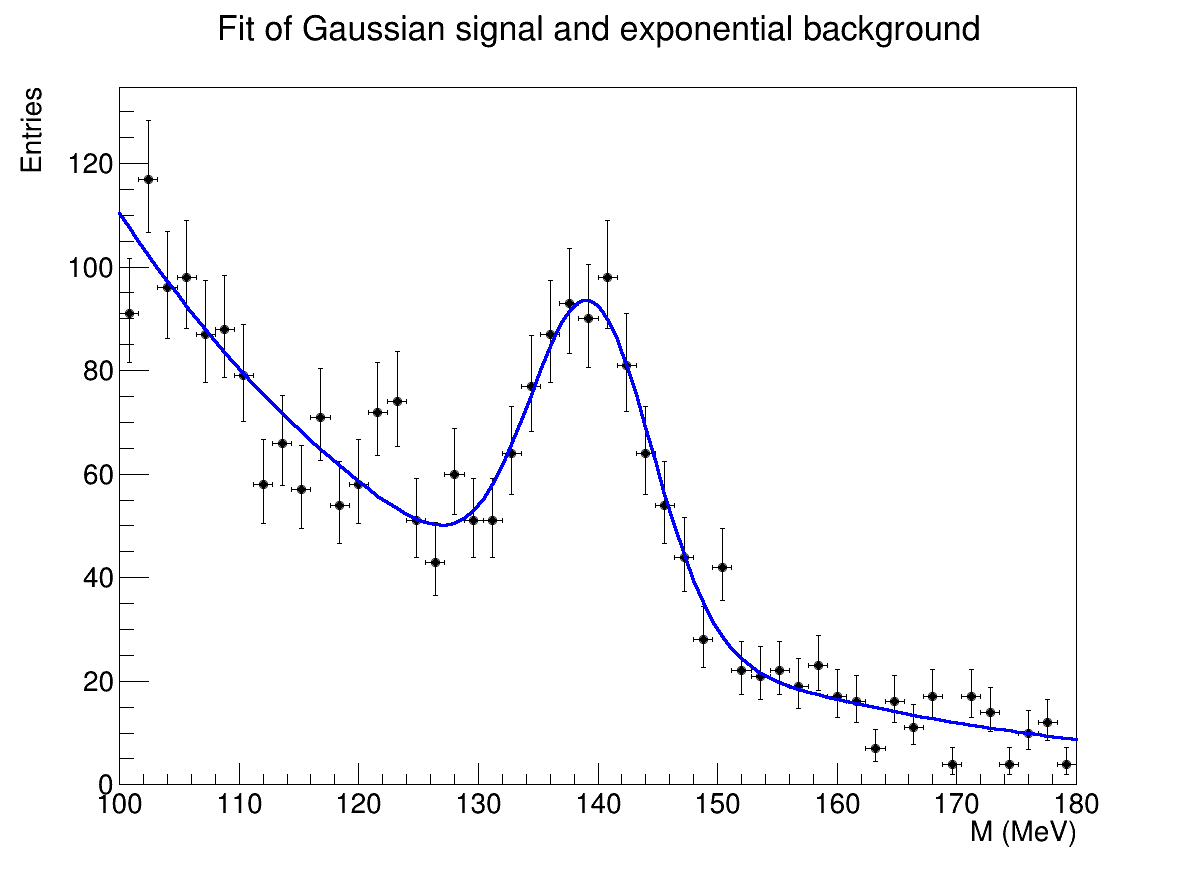

In [12]:
TCanvas c("c", "", 1200, 900);
auto myFrame = M.frame();
myFrame->SetTitle("Fit of Gaussian signal and exponential background;M (MeV);Entries");
OriginalData->plotOn(myFrame, Binning(50));
Model.plotOn(myFrame, LineColor(kBlue));
myFrame->Draw();
c.Draw();

### Function for resampling a dataset

In [13]:
RooDataSet ResampleData(const RooDataSet &OriginalDataset, RooRealVar &x) {
    static std::size_t Counter = 0;
    RooDataSet ResampledData(("ResampledData_" + std::to_string(Counter)).c_str(),
                             ("ResampledData_" + std::to_string(Counter)).c_str(), x);
    Counter++;
    std::size_t N = OriginalDataset.numEntries();
    for(std::size_t i = 0; i < N; i++) {
        std::size_t RandomInt = gRandom->Integer(N);
        double DataPoint = static_cast<RooRealVar*>(*OriginalDataset.get(RandomInt)->begin())->getVal();
        x.setVal(DataPoint);
        ResampledData.add(x);
    }
    return ResampledData;
}

### Histogram containing resampled values

In [14]:
TH1D Hist("Hist", "Hist", 100, 0.0, 0.0);

### Do the bootstrapping

In [15]:
std::size_t NumberBootstraps = 10;
for(std::size_t i = 0; i < NumberBootstraps; i++) {
    auto ResampledData = ResampleData(*OriginalData, M);
    Model.fitTo(ResampledData, PrintEvalErrors(-1), PrintLevel(-1));
    Hist.Fill(Nsig.getVal());
}

### Plot resampled values

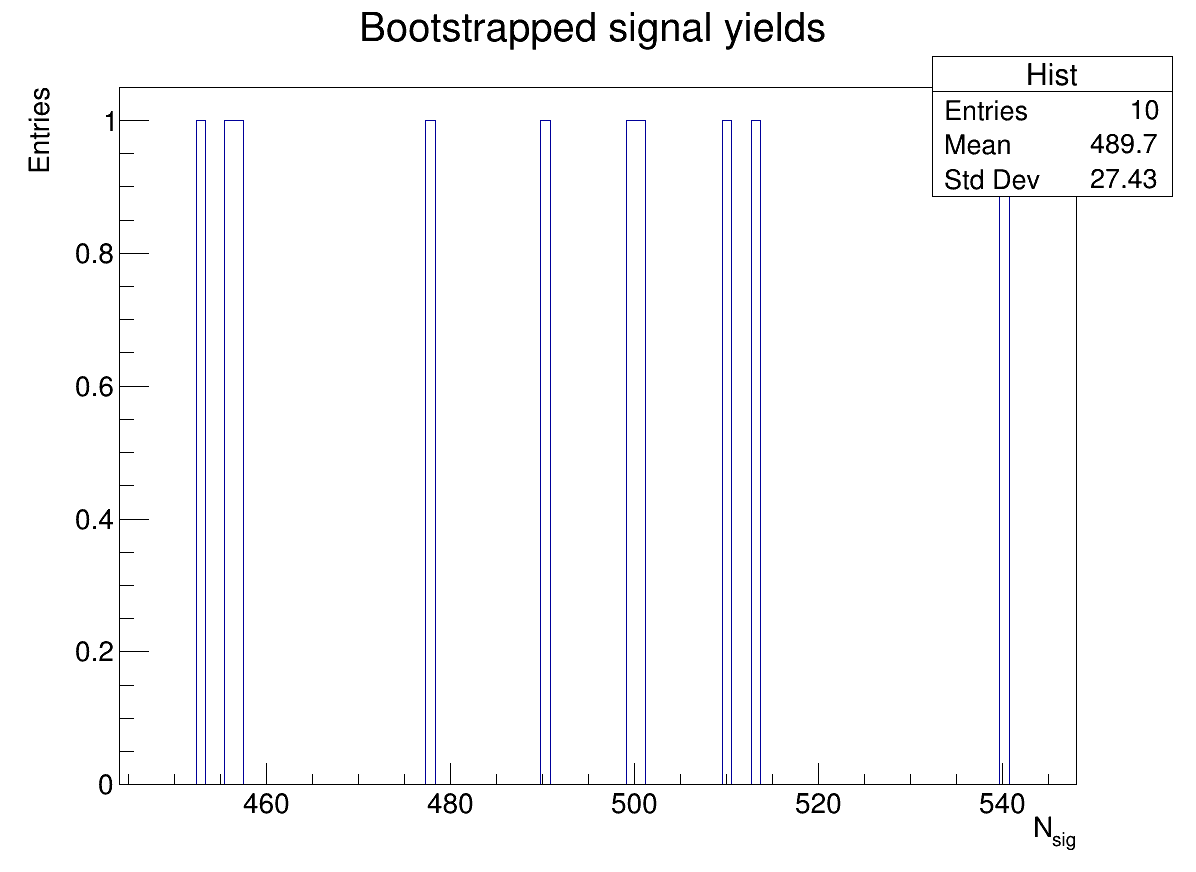

In [16]:
TCanvas c2("c2", "", 1200, 900);
Hist.SetTitle("Bootstrapped signal yields;N_{sig};Entries");
Hist.Draw("HIST");
c2.Draw();

In [17]:
Hist.Fit("gaus");

 FCN=0.000255731 FROM MIGRAD    STATUS=CONVERGED     172 CALLS         173 TOTAL
                     EDM=6.8743e-07    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   3.6 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     1.00508e+00   3.09974e-01   6.86184e-04   1.37112e-03
   2  Mean         4.91965e+02   8.25748e+02   2.95748e-01   1.37967e-06
   3  Sigma        2.72701e+02   1.81227e+02   1.13021e-01  -1.91120e-05


### Histogram with pulls from toy fits

In [18]:
TH1D ToyHist("ToyHist", "", 100, 0.0, 0.0);
TH1D ToyValues("ToyValues", "", 100, 0.0, 0.0);

### Fit toys and save pulls

In [19]:
for(std::size_t i = 0; i < NumberToys; i++) {
    Model.fitTo(ToyData[i], PrintEvalErrors(-1), PrintLevel(-1));
    ToyHist.Fill((Nsig.getVal() - Yield)/Nsig.getError());
    ToyValues.Fill(Nsig.getVal());
}

### Plot pull histogram

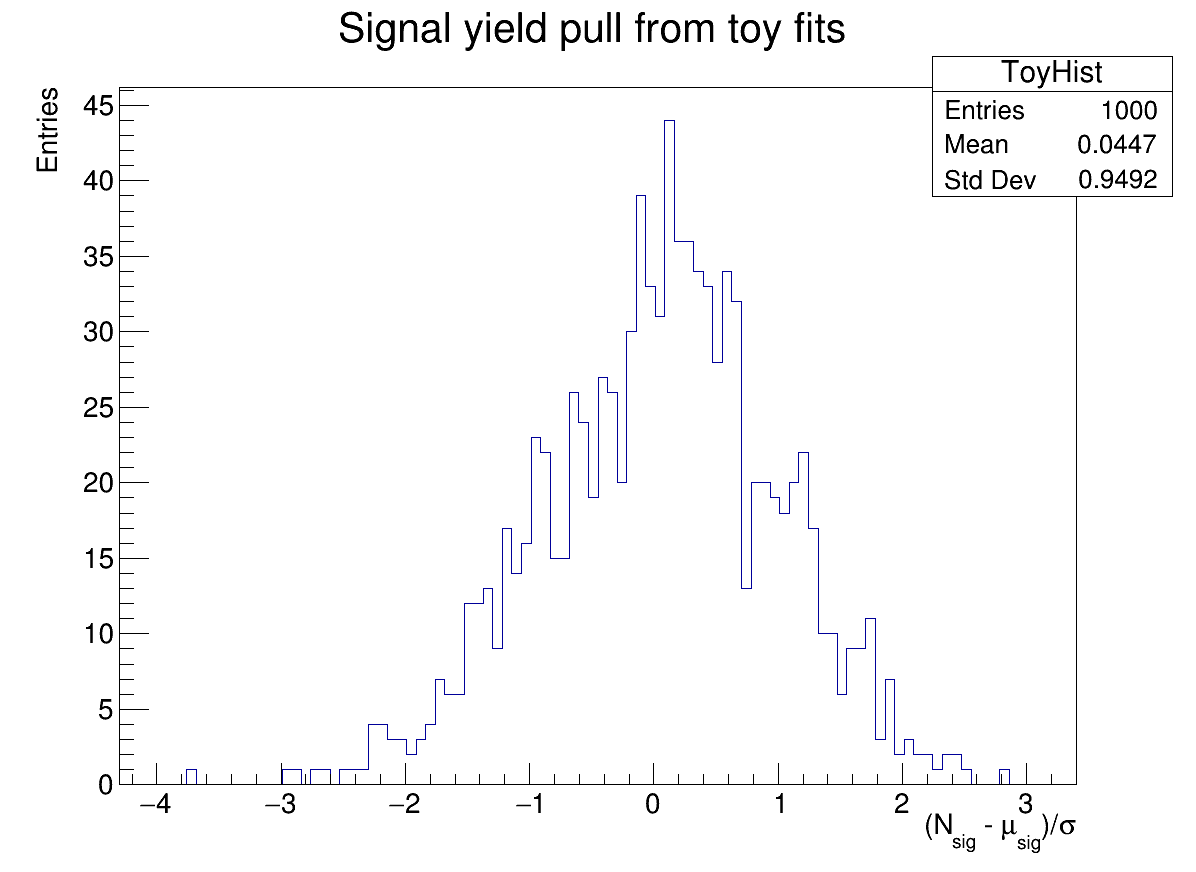

In [20]:
TCanvas c3("c3", "", 1200, 900);
ToyHist.SetTitle("Signal yield pull from toy fits;(N_{sig} - #mu_{sig})/#sigma;Entries");
ToyHist.Draw("HIST");
c3.Draw();

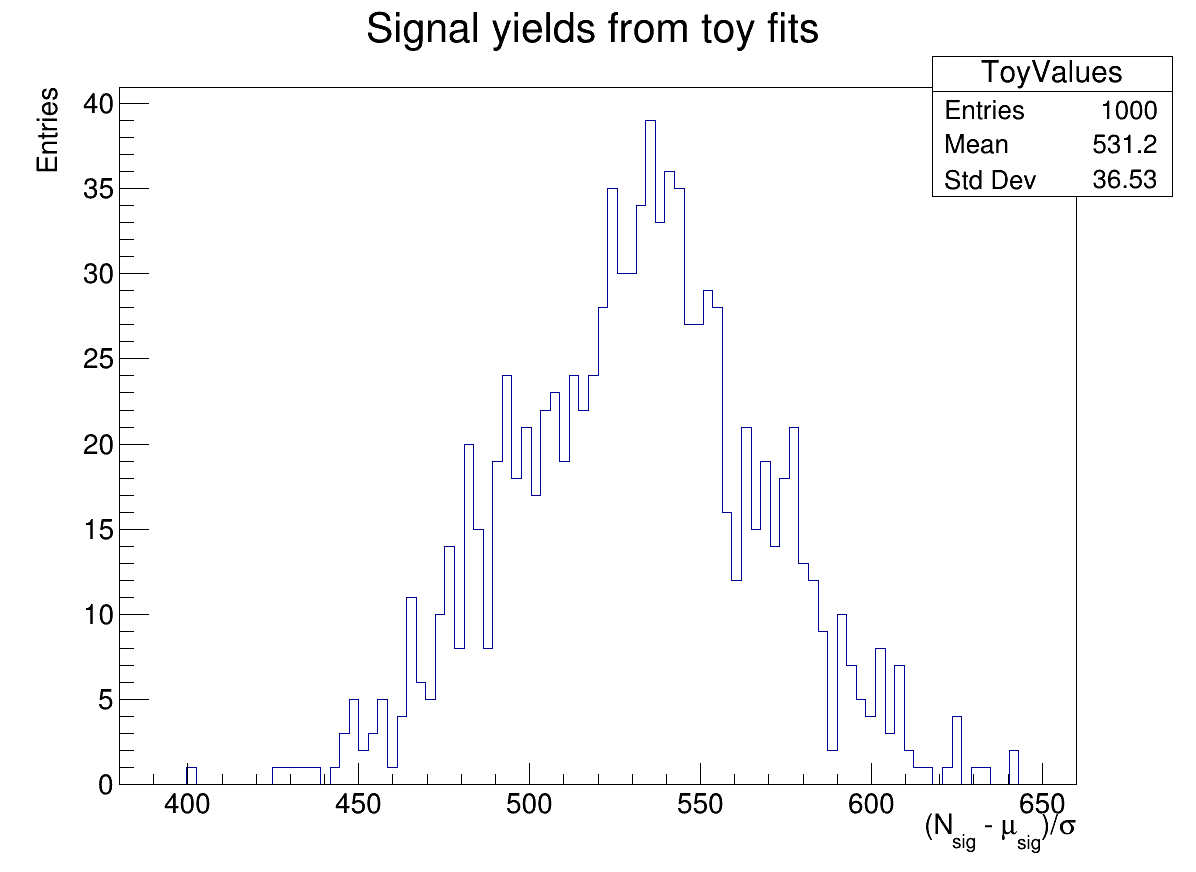

In [21]:
TCanvas c4("c4", "", 1200, 900);
ToyValues.SetTitle("Signal yields from toy fits;(N_{sig} - #mu_{sig})/#sigma;Entries");
ToyValues.Draw("HIST");
c4.Draw();